# Trajectory and velocity analysis of scRNAseq COLON data 

This is one in the series of notebooks presenting the data analysis done in the study "Widespread epithelial dedifferentiation in patients with ulcerative colitis". It is also intended as a tutorial in scRNAseq analysis. Please refer to the REAMDE file for the description of different parts of the tutorial and how to follow it.  

## Part 5. RNA velocity

### Healthy progenitors dataset

This notebook shows the pipeline done on the "Healthy progenitor dataset" (see study for details regarding samples constituting the dataset). Healthy progeniotors are the cells from the healthy dataset that were determined (in Part 2) to be in the G2M or S cell cycle phase and as such are such are understood to be progenitors of the more differentiated cells. I am not providing detailed descriptions of each step here. Those can be found in the notebook for the Healthy dataset. Please refer to the file `Healthy_velo.ipynb`

#### 0. Imports and settings

In [1]:
import scanpy as sc
import scvelo as scv
import numpy as np

In [2]:
scv.settings.set_figure_params('scvelo', dpi=75, vector_friendly=True, figsize=[6,6])

#### 1. Load data

In [3]:
adata = sc.read('healthy_de_progen.h5ad')

#### 2. Velocity computation

In [4]:
scv.pp.moments(adata, n_pcs=30, n_neighbors=20)
scv.tl.recover_dynamics(adata)
scv.tl.velocity(adata)

computing moments based on connectivities
    finished (0:00:06) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
recovering dynamics
    finished (0:10:56) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:04) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


#### 3. Differential Kinetic

In [5]:
top_genes = adata.var['fit_likelihood'].sort_values(ascending=False).index[:500]
scv.tl.differential_kinetic_test(adata, var_names=top_genes, groupby='Celltype')

testing for differential kinetics
    finished (0:01:29) --> added 
    'fit_diff_kinetics', clusters displaying differential kinetics (adata.var)
    'fit_pval_kinetics', p-values of differential kinetics (adata.var)


In [6]:
scv.tl.velocity(adata, diff_kinetics=True)
scv.tl.velocity_graph(adata, mode_neighbors='connectivities')

computing velocities
    finished (0:00:04) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph
    finished (0:00:02) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


#### 4. Latent time 

In [7]:
scv.tl.terminal_states(adata)
scv.tl.latent_time(adata)

computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:02) --> added 
    'latent_time', shared time (adata.obs)


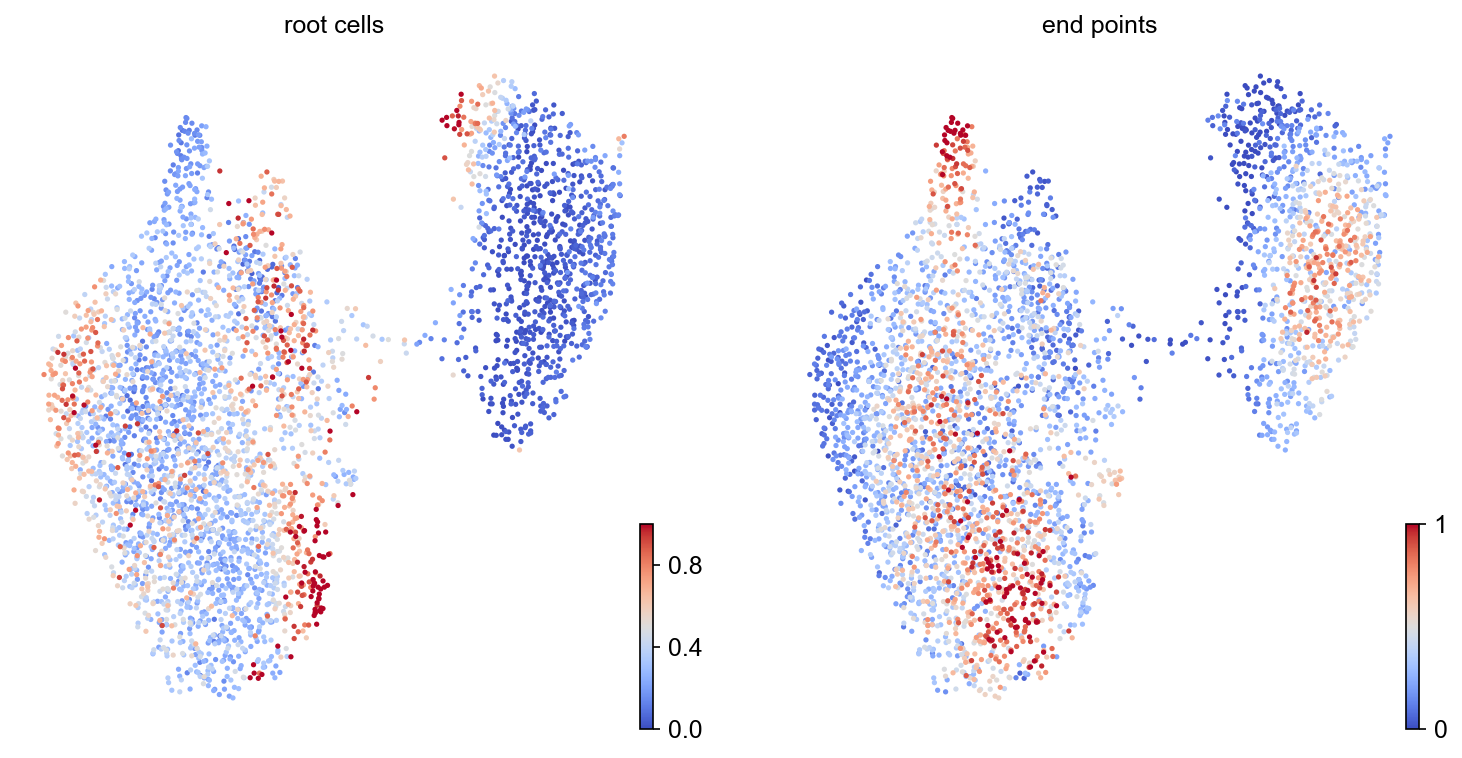

In [8]:
scv.pl.scatter(adata, color=['root_cells', 'end_points'], legend_loc='right margin',
               cmap='coolwarm', perc=[2, 98], colorbar=True, rescale_color=[0,1])

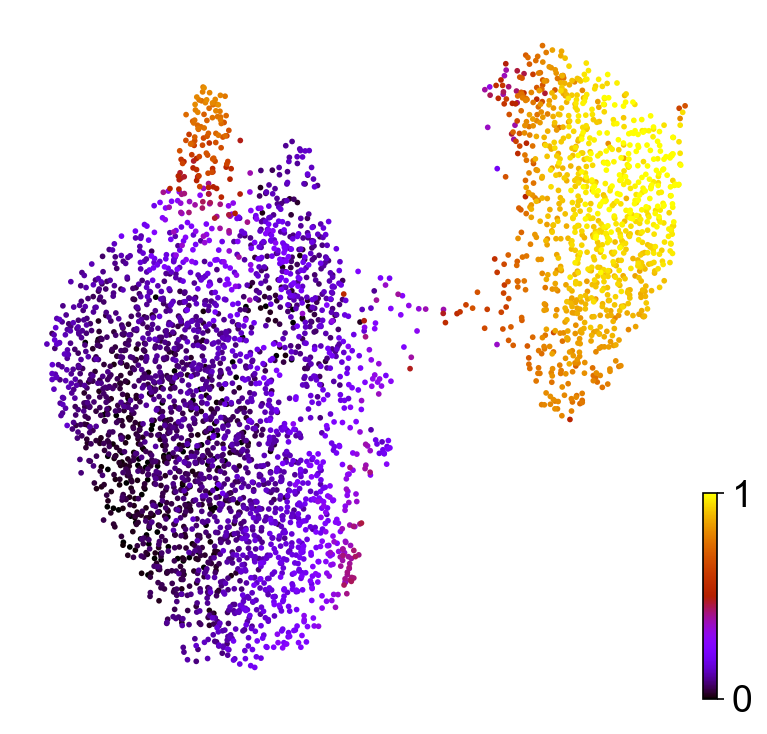

In [9]:
scv.pl.scatter(adata, color='latent_time', fontsize=24, size=30, basis='umap',
               color_map='gnuplot', perc=[2, 98], colorbar=True, rescale_color=[0,1],
               title='')

#### 5. Plotting velocity on embeddings

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


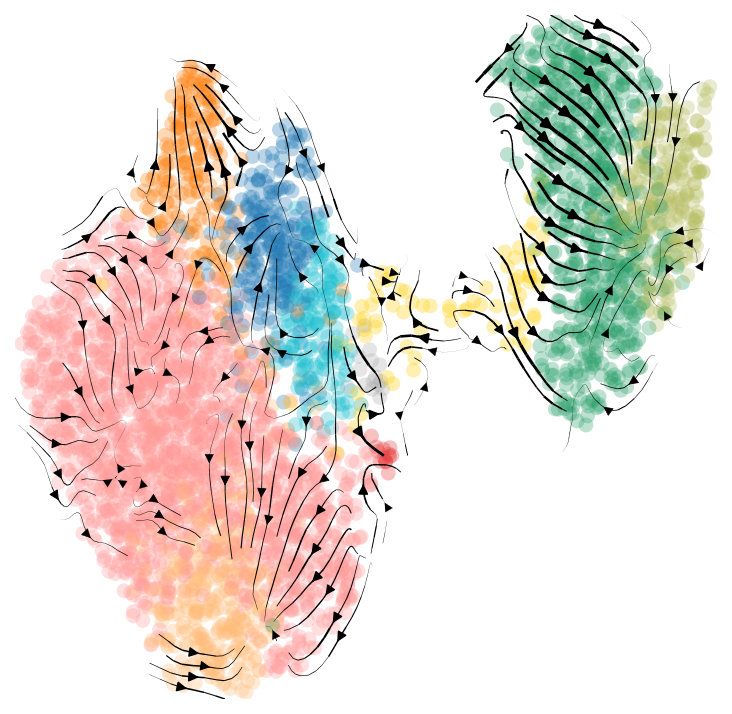

In [10]:
scv.pl.velocity_embedding_stream(adata, basis='umap', 
                                 legend_fontsize=10, title='', 
                                 smooth=.52, min_mass=0, color='Celltype',
                                 legend_loc='none')

computing velocity embedding
    finished (0:00:01) --> added
    'velocity_pca', embedded velocity vectors (adata.obsm)


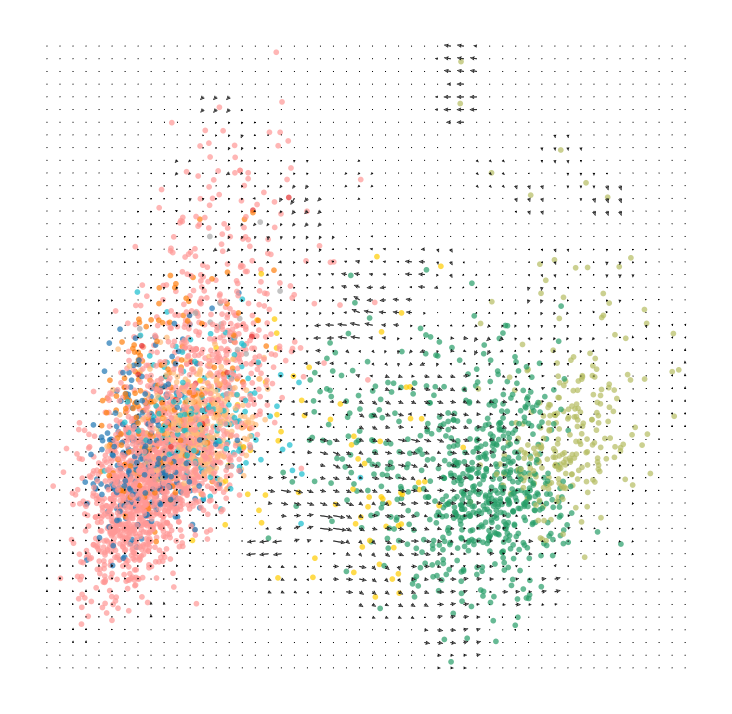

In [11]:
scv.pl.velocity_embedding_grid(adata, basis='pca', 
                                 legend_fontsize=10, title='', 
                                 smooth=.52, min_mass=0, color='Celltype',
                                 alpha=0.7, size=30, fontsize=30, legend_loc='none')

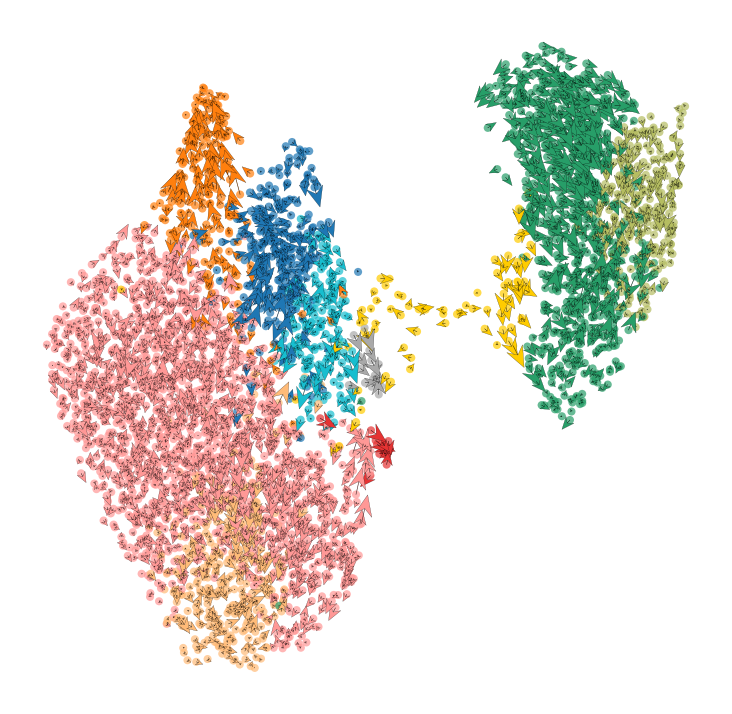

In [12]:
scv.pl.velocity_embedding(adata, basis='umap', 
                                 arrow_size=5, arrow_length=5, title='', 
                                 alpha=0.7, size=60, color='Celltype',
                                 legend_loc='none')

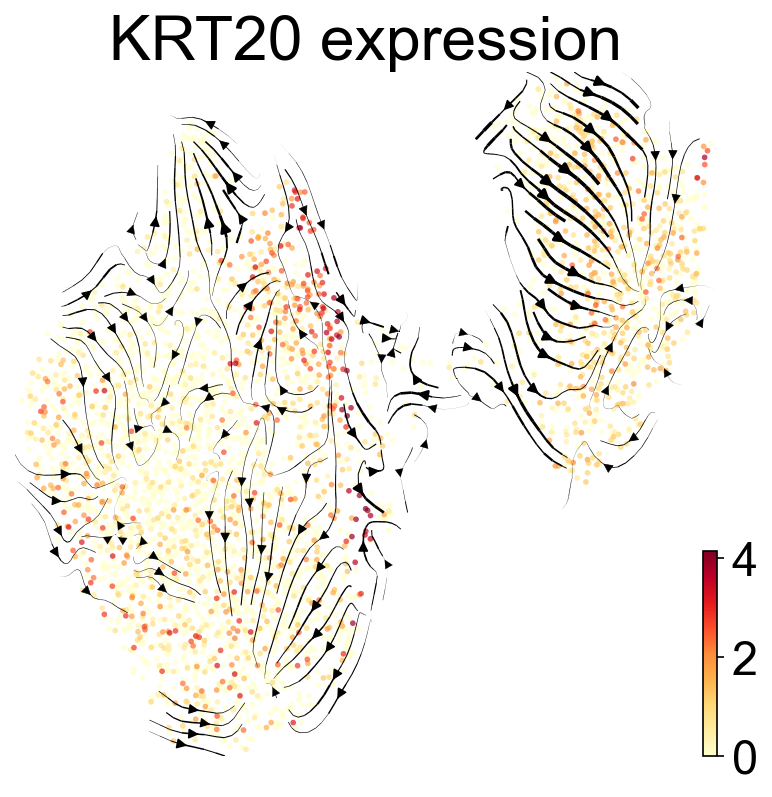

In [13]:
gene = "KRT20"
scv.pl.velocity_embedding_stream(adata, basis='umap', cmap='YlOrRd',
                                 legend_fontsize=10, title='{} expression'.format(gene), 
                                 smooth=.52, min_mass=0, color=gene,
                                 alpha=0.7, size=30, fontsize=30, legend_loc='none')

#### 6. Velocity quality control

--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


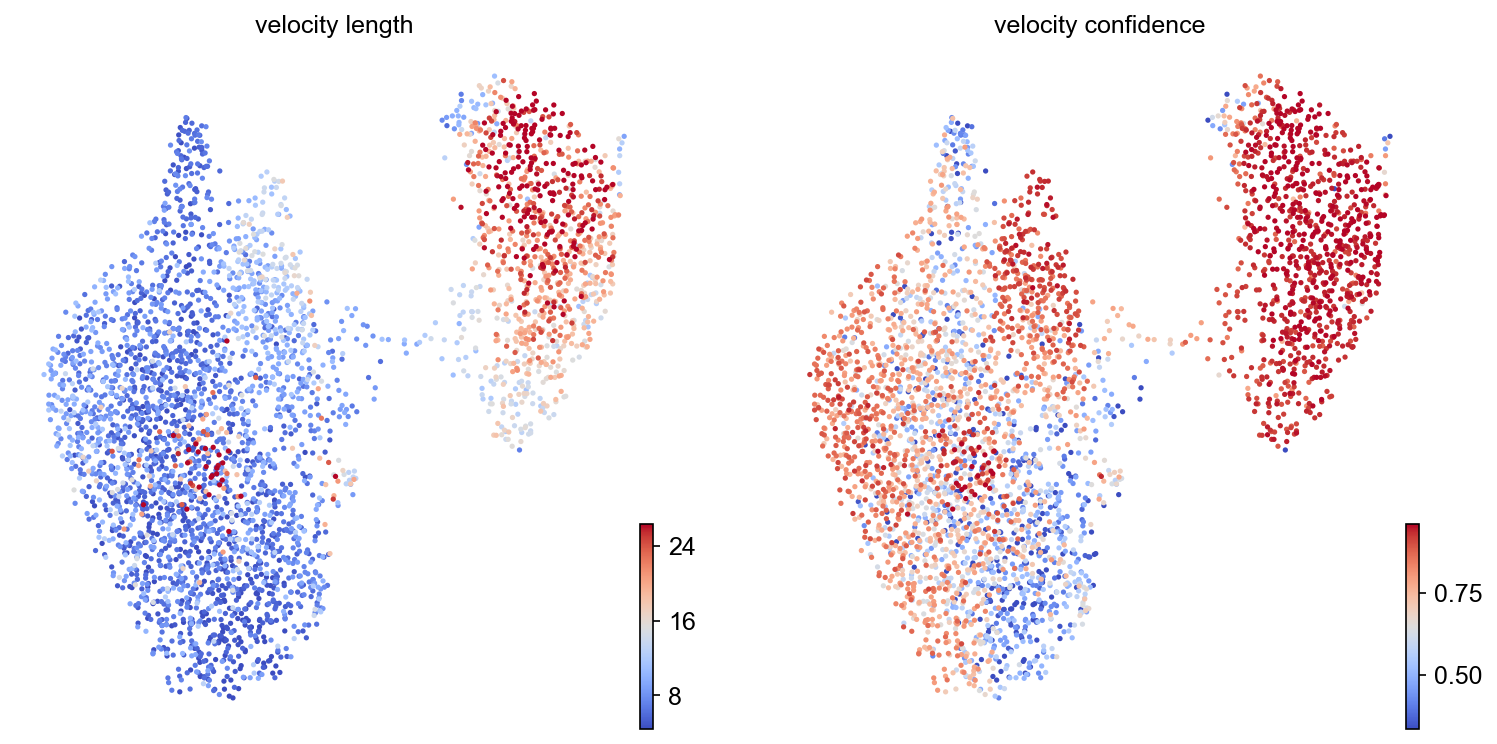

In [14]:
scv.tl.velocity_confidence(adata)
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata, c=keys, cmap='coolwarm', perc=[5, 95])

In [15]:
df = adata.obs.groupby('Celltype')[keys].mean().T
df.style.background_gradient(cmap='coolwarm', axis=1)

Celltype,Stem,TA SOX4+,TA Colonocytes,Colonocytes,TA BEST4+,BEST4+,TA Goblet,Goblet,EECs,Tuft
velocity_length,6.340721,10.849334,7.969290,6.254783,10.629775,10.254783,20.813982,21.374567,13.812000,8.601875
velocity_confidence,0.596312,0.724322,0.661131,0.599806,0.833961,0.782923,0.914504,0.930958,0.611565,0.486160


#### 7. PAGA velocity graph

In [16]:
# Those steps are currently necessary due to a bug in code. May change in future updates.
adata.uns['neighbors']['distances'] = adata.obsp['distances']
adata.uns['neighbors']['connectivities'] = adata.obsp['connectivities']

In [17]:
scv.tl.paga(adata, groups='Celltype', root_key='root_cells', end_key='end_points', use_time_prior=False)

running PAGA using priors: ['root_cells', 'end_points']
    finished (0:00:00) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


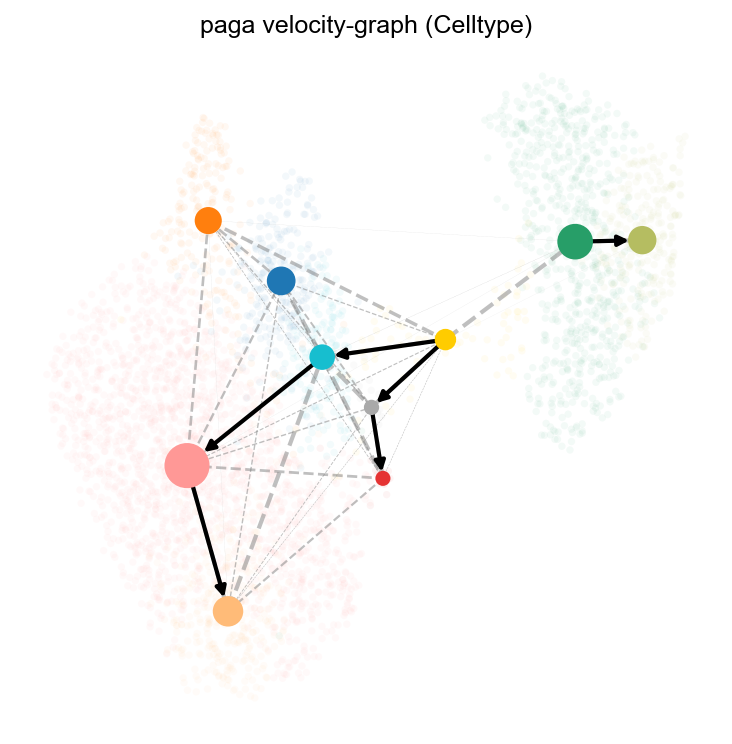

In [18]:
scv.pl.paga(adata, basis='umap', size=50, alpha=.05, color='Celltype',
            min_edge_width=2, node_size_scale=1, legend_loc='none', arrowsize=10)

In [19]:
scv.tl.paga(adata, groups='SubCelltype', root_key='root_cells', end_key='end_points', use_time_prior=False)

running PAGA using priors: ['root_cells', 'end_points']
    finished (0:00:00) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


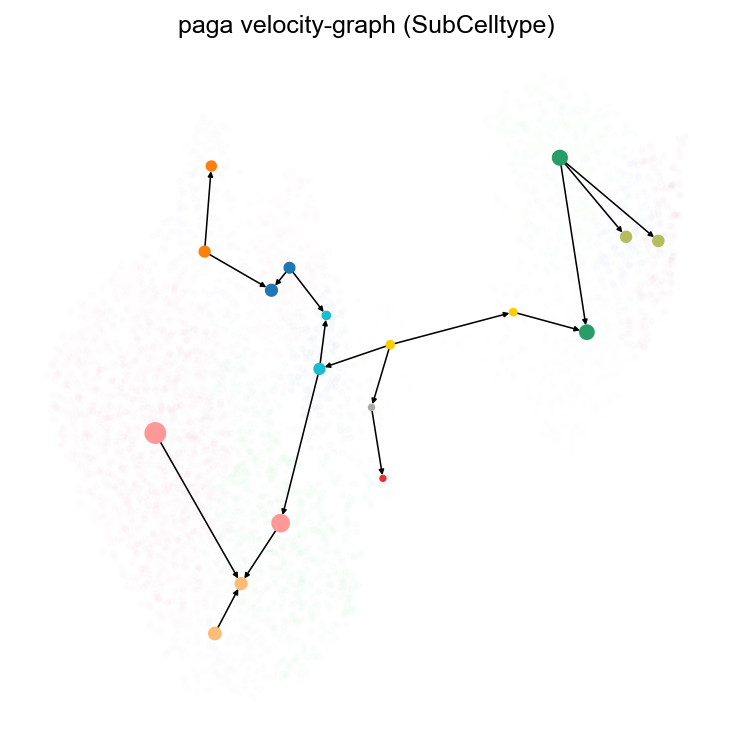

In [20]:
scv.pl.paga(adata, basis='umap', size=50, alpha=.02, color='Celltype', dashed_edges=None,
            min_edge_width=0.75, node_size_scale=0.2, legend_loc='none', arrowsize=5)

#### 8. Save data for the next step 

In [21]:
adata.write("healthy_velo_progen.h5ad")